In [27]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from sheet1 import gammaidx, auc

In [3]:
data = np.load('problem_set1/data/banana.npz')

In [4]:
print(data.files)

['data', 'label']


In [15]:
X = data['data'].T
y = data['label'].T.squeeze()

In [20]:
X_in = X[y == 1]

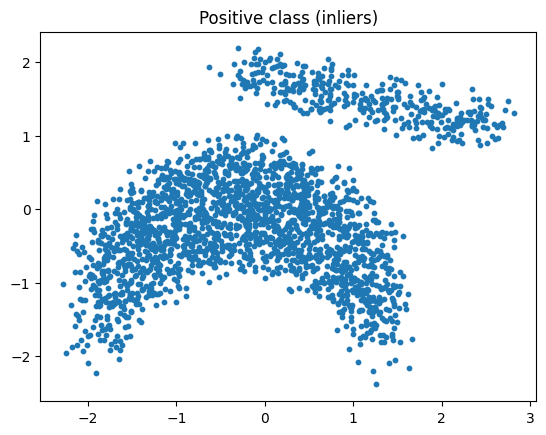

In [21]:
plt.scatter(X_in[:, 0], X_in[:, 1], s=10)
plt.title("Positive class (inliers)")
plt.show()

In [ ]:
def run_experiment(X_in, rate):
    n_in = len(X_in)
    n_out = int(rate * n_in)

    X_out = np.random.uniform(-4, 4, size=(n_out, 2))

    X_full = np.vstack([X_in, X_out])

    y_true = np.hstack([
        np.ones(n_in),
        -np.ones(n_out)
    ])

    g3 = gammaidx(X_full, 3)
    g10 = gammaidx(X_full, 10)

    mean = np.mean(X_full, axis=0)
    dmean = np.linalg.norm(X_full - mean, axis=1)

    # auc
    auc_g3 = auc(y_true, -g3)
    auc_g10 = auc(y_true, -g10)
    auc_mean = auc(y_true, -dmean)

    return auc_g3, auc_g10, auc_mean

In [25]:
contamination_rates = [0.01, 0.1, 0.5, 1.0]

In [29]:
results = {}

for rate in contamination_rates:

    aucs_g3 = []
    aucs_g10 = []
    aucs_mean = []
    
    for _ in tqdm(range(100)):

        a1, a2, a3 = run_experiment(X_in, rate)

        aucs_g3.append(a1)
        aucs_g10.append(a2)
        aucs_mean.append(a3)

    results[rate] = {
        'g3': aucs_g3,
        'g10': aucs_g10,
        'mean': aucs_mean
    }

100%|██████████| 100/100 [07:59<00:00,  4.79s/it]


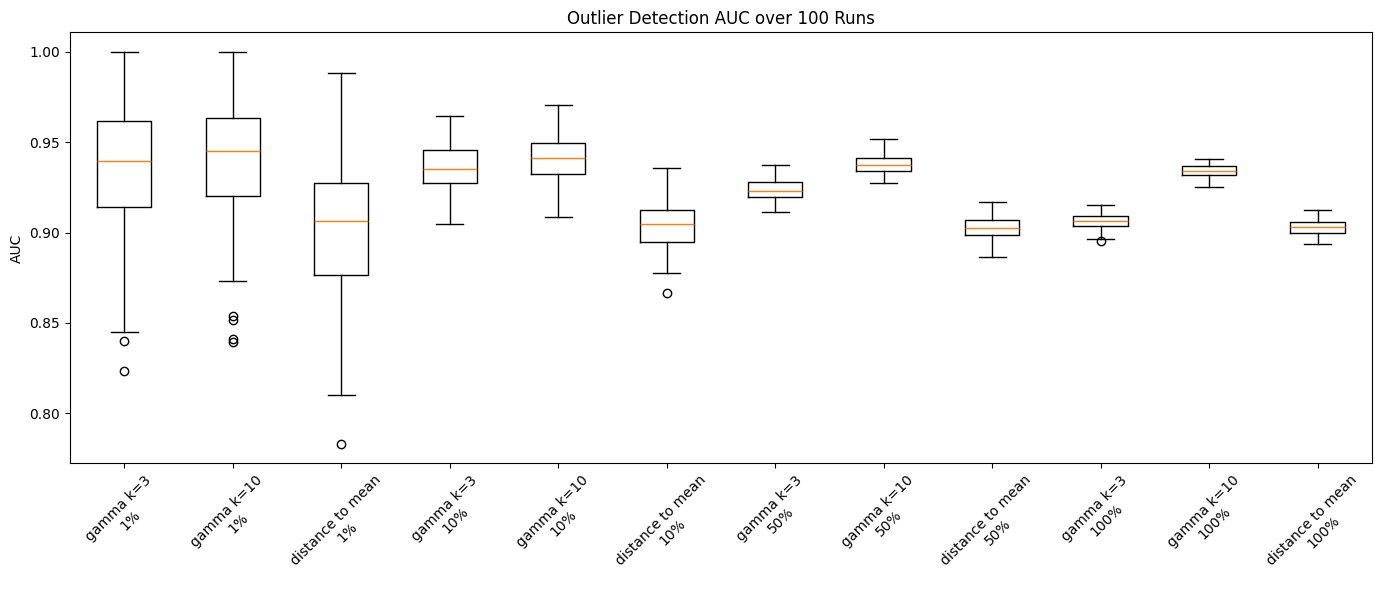

In [40]:
plt.figure(figsize=(14, 6))

all_data = []
labels = []

for rate in contamination_rates:

    all_data.append(results[rate]['g3'])
    labels.append(f'gamma k=3\n{int(rate*100)}%')

    all_data.append(results[rate]['g10'])
    labels.append(f'gamma k=10\n{int(rate*100)}%')

    all_data.append(results[rate]['mean'])
    labels.append(f'distance to mean\n{int(rate*100)}%')

plt.boxplot(all_data)

plt.xticks(
    ticks=np.arange(1, len(labels)+1),
    labels=labels,
    rotation=45
)

plt.ylabel('AUC')
plt.title('Outlier Detection AUC over 100 Runs')

plt.tight_layout()
plt.show()

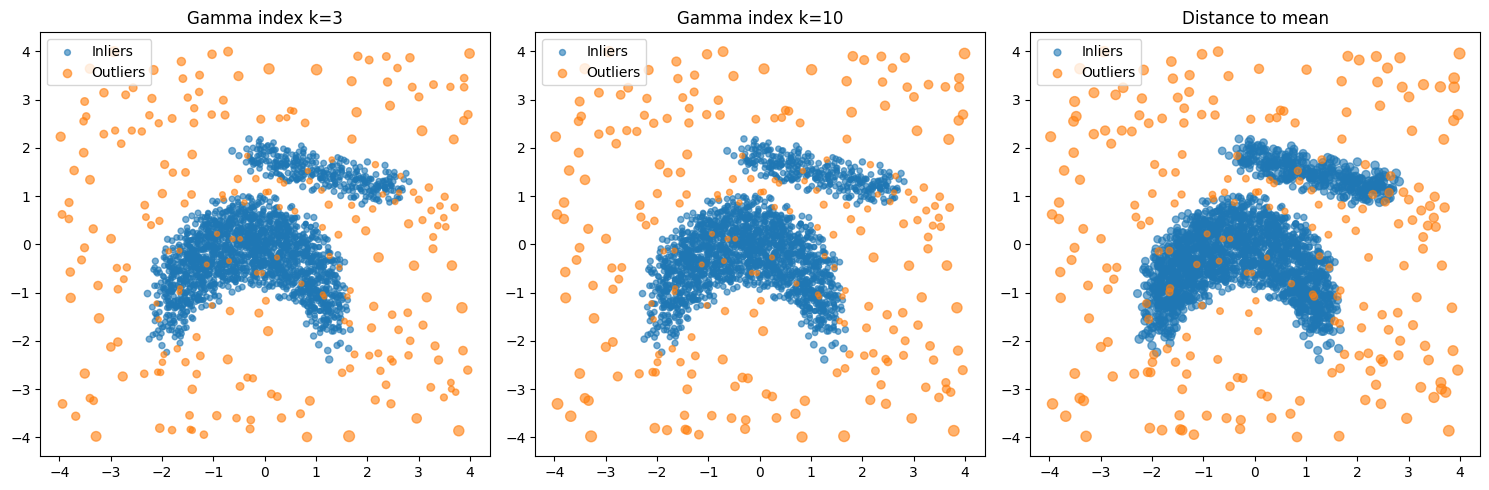

In [41]:
rate = 0.1

n_in = len(X_in)
n_out = int(rate * n_in)

X_out = np.random.uniform(-4, 4, size=(n_out, 2))

X_full = np.vstack([X_in, X_out])

labels = np.hstack([
    np.ones(n_in),
    -np.ones(n_out)
])

scores_g3 = gammaidx(X_full, 3)
scores_g10 = gammaidx(X_full, 10)

mean = np.mean(X_full, axis=0)
scores_mean = np.linalg.norm(X_full - mean, axis=1)

def make_sizes(scores):
    s = (scores - scores.min()) / (scores.max() - scores.min())
    return 10 + 50 * s

sizes_g3 = make_sizes(scores_g3)
sizes_g10 = make_sizes(scores_g10)
sizes_mean = make_sizes(scores_mean)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

methods = [
    ("Gamma index k=3", scores_g3, sizes_g3),
    ("Gamma index k=10", scores_g10, sizes_g10),
    ("Distance to mean", scores_mean, sizes_mean)
]

for ax, (title, scores, sizes) in zip(axes, methods):

    ax.scatter(
        X_full[labels == 1, 0],
        X_full[labels == 1, 1],
        s=sizes[labels == 1],
        label="Inliers",
        alpha=0.6
    )

    ax.scatter(
        X_full[labels == -1, 0],
        X_full[labels == -1, 1],
        s=sizes[labels == -1],
        label="Outliers",
        alpha=0.6
    )

    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()